In [73]:
# Configure path.
import sys; import os
sys.path.append(os.path.abspath('..'))

%matplotlib inline
import numpy as np
import scipy, importlib, itertools
import matplotlib.pyplot as plt
plt.style.use('dissertation.mplstyle')

import python.forces as forces
import python.integrators as integrators
import python.random_matrix as random_matrix 
import python.simulate as simulate
import python.densities as densities

importlib.reload(forces); importlib.reload(integrators); importlib.reload(random_matrix)
importlib.reload(simulate); importlib.reload(densities);

---

Testing the universality of random matrices (for Wigner $\beta$-ensembles).
- Macroscropic eigenvalue density should approach semicircle/quartic double well, irrespective of $\beta$.
- Microscropic density should approach distribution according to Wigner surmise, irrespective of potential.

In [88]:
# Thank you to https://robertsweeneyblanco.github.io/Computational_Random_Matrix_Theory/Eigenvalues/Wigner_Surmise.html.
gamma_func = lambda x: scipy.special.gamma(x)

def wigner_surmise(s, beta):
    a = 2*(gamma_func((beta+2)/2))**(beta+1)/(gamma_func((beta+1)/2))**(beta + 2)
    b = (gamma_func((beta+2)/2))**2/(gamma_func((beta+1)/2))**2
    
    return a * (s**beta) * np.exp(-b*s**2)

def plot_gaps(ax, particles, beta, potential, dt, N):
        # Plotter helper.
        s_range = np.linspace(0, 3.5, 500)
        surmise = wigner_surmise(s_range, beta) # as above

        final_states = particles.reshape(-1, N)
        sorted_states = np.sort(final_states, axis = 1)
        gaps = np.diff(sorted_states, axis = 1).flatten()
        normalised_gaps = gaps/np.mean(gaps)
        
        # Plotter:       
        ax.hist(normalised_gaps, bins = 100, density = True, color = "steelblue", edgecolor = "black", alpha = 0.75)
        ax.plot(s_range, surmise, color = "red", lw = 2, label = rf"$\beta$ = {beta}")
        ax.axvline(2*np.sqrt(dt), label = r"2$\sqrt{\Delta t}$", linestyle = "--", color = "orange", lw = 1)
        
        ax.grid(False)
        ax.set_title(f"{potential.capitalize()}, beta = {beta}.")
        ax.set_xlim(0, 4)

        return ax

def plot_macroscopic(ax, particles, beta, potential):
    ax.hist(particles, bins = 30, density = True, color = "steelblue", edgecolor = "black", alpha = 0.75)
    ax.set_title(f"{potential.capitalize()}, beta = {beta}.")
    ax.grid(False)

    return ax    

Running quadratic for beta = 4.


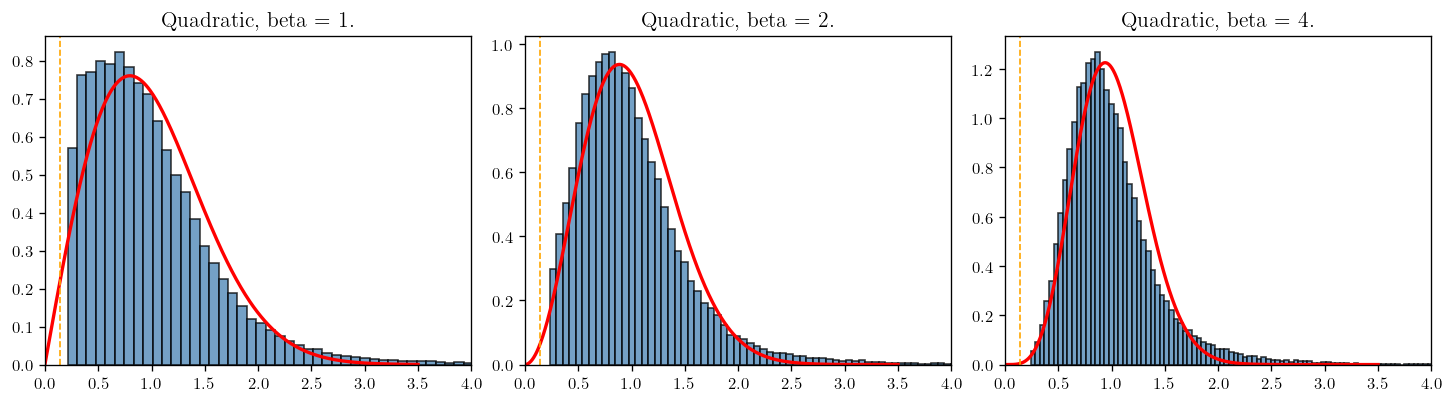

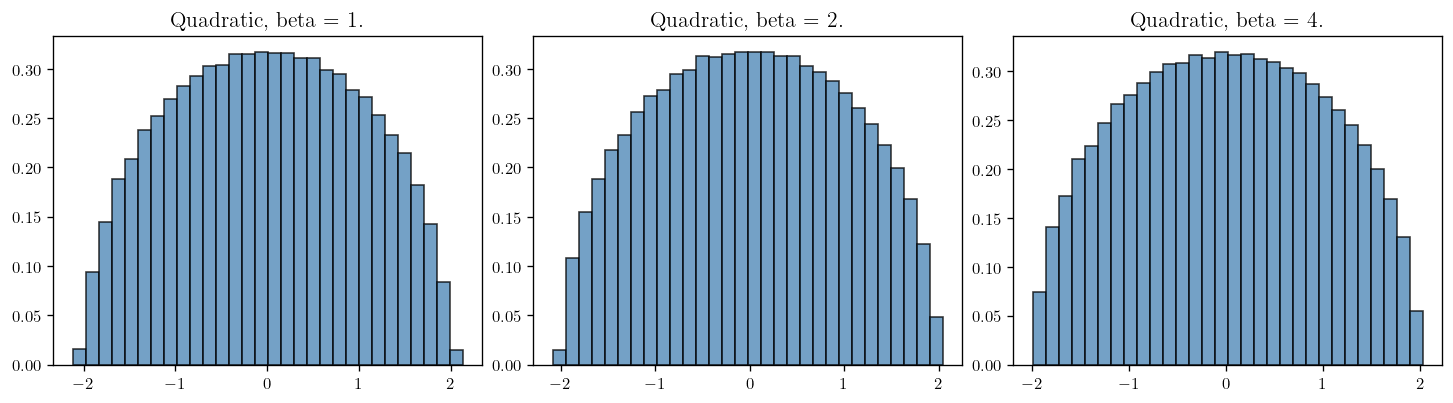

Running quartic for beta = 4.


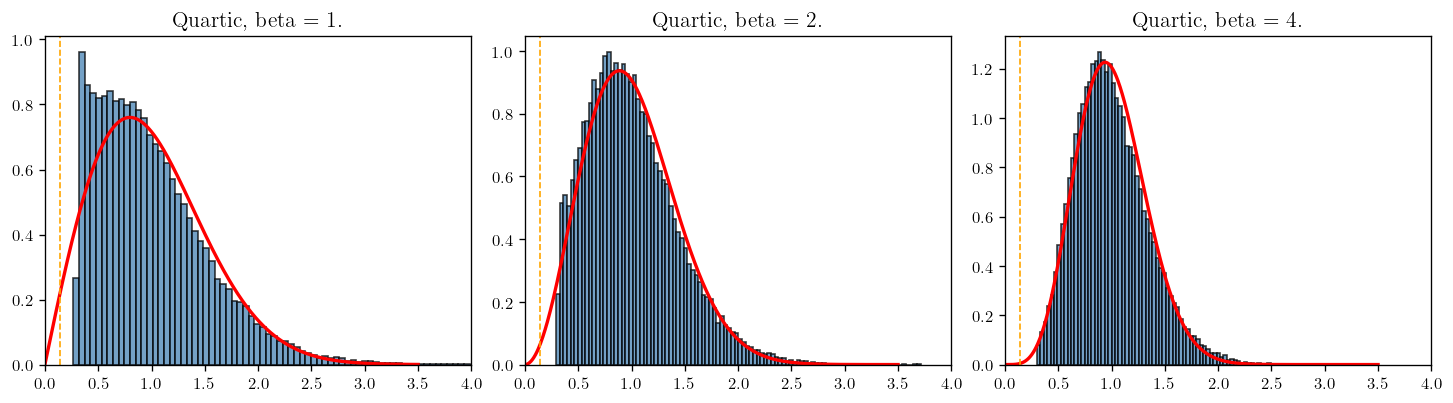

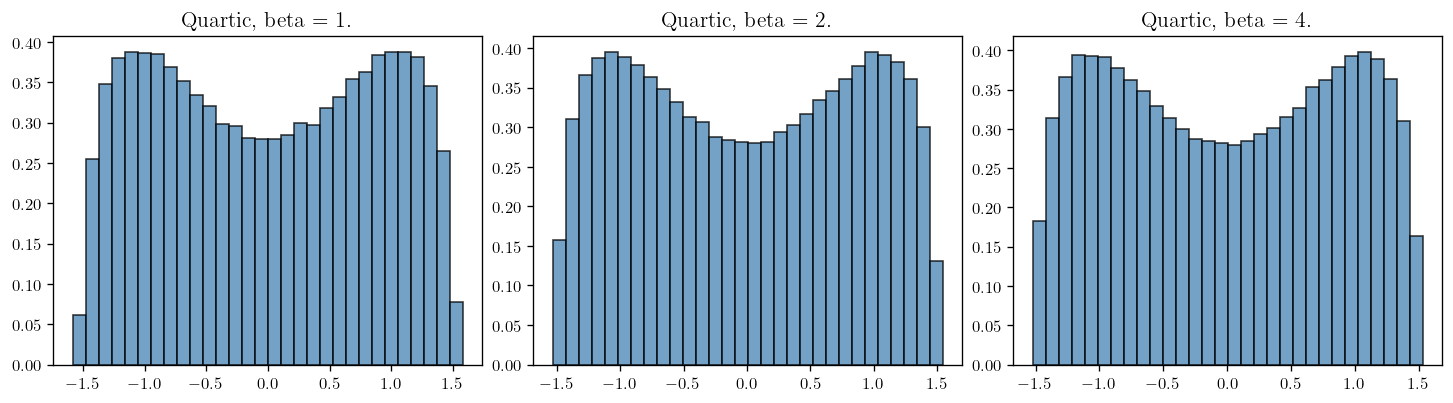

In [89]:
N = 100; T = 5.0; M = 100; 
dt = 0.005; total_steps = int(T/dt);

betas = [1, 2, 4]
potentials = ["quadratic", "quartic"]

for potential in potentials:
    print(f"Running {potential} for beta = {beta}.")
    fig, axes = plt.subplots(1, len(betas), figsize = (4*len(betas), 3.25))
    fig2, axes2 = plt.subplots(1, len(betas), figsize = (4*len(betas), 3.25))

    for j, beta in enumerate(betas):
        init = random_matrix.init_gue_eigenvalues(M, N)
        noise_scale = np.sqrt(2.0*dt/(beta*N))

        implicit_pipe = simulate.make_implicit_pipeline(dt, noise_scale, beta, potential)
        traj = simulate.simulate_dbm(init, total_steps, implicit_pipe)
        particles = simulate.collect_snapshots(traj, total_steps)

        plot_gaps(axes[j], particles, beta, potential, dt, N)
        plot_macroscopic(axes2[j], particles, beta, potential)

    plt.show()